In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
import imageio.v2 as imageio
from pathlib import Path

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


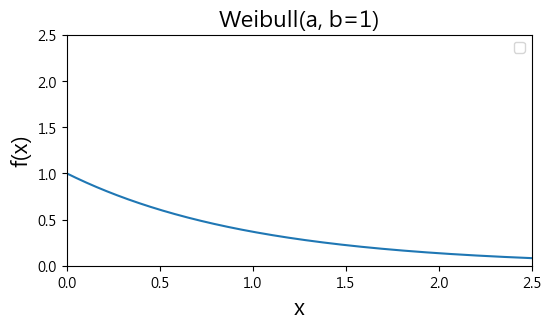

In [31]:
def Weibull(x, a, b):
    if a<=0 and b<=0:
        raise ValueError('a and b must be positive')
    x = np.asarray(x, dtype='float')
    y = np.zeros_like(x)
    mask = x >= 0
    xm = x[mask]
    y = (b/a)*(xm/a)**(b-1)*np.exp(-(xm/a)**b)
    return y
a = 1
b = 1
x = np.linspace(0, 2.5, 500)
y = Weibull(x, a, b)
plt.figure(figsize=(6, 3))
plt.plot(x, y)
plt.title('Weibull(a, b=1)', fontsize=16)
plt.xlabel('x', fontsize=16)
plt.ylabel('f(x)', fontsize=16)
plt.xlim(0, 2.5)
plt.ylim(0, 2.5)
plt.legend()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_34872\603649450.py:8: RuntimeWarning: divide by zero encountered in power
  y = (b/a)*(xm/a)**(b-1)*np.exp(-(xm/a)**b)


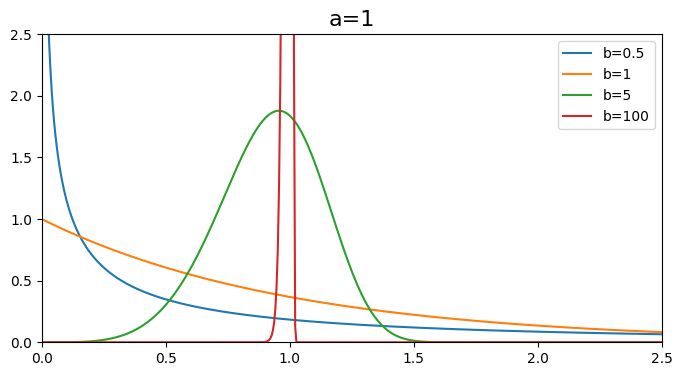

In [10]:
def Weibull(x, a, b):
    if a<=0 and b<=0:
        raise ValueError('a and b must be positive')
    x = np.asarray(x, dtype='float')
    y = np.zeros_like(x)
    mask = x >= 0
    xm = x[mask]
    y = (b/a)*(xm/a)**(b-1)*np.exp(-(xm/a)**b)
    return y
a = 1
b_list = [0.5, 1, 5, 100]
x = np.linspace(0, 2.5, 500)

plt.figure(figsize=(8, 4))
for b in b_list:
    y = Weibull(x, a, b)
    plt.plot(x, y, label=f'b={b}')
plt.title('a=1', fontsize=16)
plt.xlim(0, 2.5)
plt.ylim(0, 2.5)
plt.legend()
plt.show()

In [30]:

def Weibull(x, a, b):
    if (a <= 0) or (b <= 0):
        raise ValueError("a and b must be positive")
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    mask = x >= 0
    xm = x[mask]
    y[mask] = (b/a) * (xm/a)**(b-1) * np.exp(-(xm/a)**b)
    return y

# ====== 設定 ======
a = 1.0
x = np.linspace(0, 2.5, 600)

# 建議用 log-space 讓 b 從小到大變化更平滑
b_vals = np.geomspace(0.5, 100, 60)  # 60 frames: b=0.5 -> 100
# 若想只跑你原本四個點，就改成: b_vals = [0.5, 1, 5, 100]

out_dir = Path("weibull_anim")
frames_dir = out_dir / "frames"
frames_dir.mkdir(parents=True, exist_ok=True)

gif_path = out_dir / "weibull_a1_b_sweep.gif"

# y 軸上限建議固定，避免動畫縮放造成視覺誤判
ymax = 2.5

# ====== 產生 frames ======
frame_paths = []
for i, b in enumerate(b_vals, start=1):
    y = Weibull(x, a, float(b))

    fig = plt.figure(figsize=(8, 4))
    ax = fig.add_subplot(111)
    ax.plot(x, y, linewidth=2)
    ax.set_title(rf"Weibull PDF ($a=1$, $b={b:.3g}$)", fontsize=16)
    ax.set_xlim(0, 2.5)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("x", fontsize=16)
    ax.set_ylabel("f(x)", fontsize=16)
    ax.grid(True, alpha=0.3)

    fp = frames_dir / f"frame_{i:03d}.png"
    fig.savefig(fp, dpi=160, bbox_inches="tight")
    plt.close(fig)
    frame_paths.append(fp)

# ====== 組 GIF ======
imgs = [imageio.imread(p) for p in frame_paths]
imageio.mimsave(gif_path, imgs, duration=0.08, loop=0)  # 0.08s/frame

print("GIF saved to:", gif_path)
print("Frames saved to:", frames_dir)

C:\Users\USER\AppData\Local\Temp\ipykernel_34872\2569458625.py:8: RuntimeWarning: divide by zero encountered in power
  y[mask] = (b/a) * (xm/a)**(b-1) * np.exp(-(xm/a)**b)


GIF saved to: weibull_anim\weibull_a1_b_sweep.gif
Frames saved to: weibull_anim\frames


In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt

def poisson_pmf(k, lam):
    return (lam**k) * math.exp(-lam) / math.factorial(k)

# 三種 λ：小/中/大
lams = [0.5, 3, 12]

# 取共同的 k 範圍（涵蓋最大 λ 的主要質量）
k_max = 30
ks = np.arange(0, k_max + 1)

plt.figure(figsize=(9, 5))

for lam in lams:
    pmf = [poisson_pmf(int(k), lam) for k in ks]
    plt.plot(ks, pmf, marker='o', linewidth=1.8, label=f'λ={lam}')

plt.title('Poisson PMF Comparison (small / medium / large λ)')
plt.xlabel('k (count)')
plt.ylabel('P(X=k)')
plt.xticks(ks)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig('PoissonCompare.png', dpi=300, bbox_inches='tight')
plt.close()

In [3]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

def poisson_pmf(k, lam):
    return (lam**k) * math.exp(-lam) / math.factorial(k)

# 參數：60 張 frame、λ 從小到大
n_frames = 60
lam_start, lam_end = 0.5, 12.0

out_dir = "poisson_anim/frames"
os.makedirs(out_dir, exist_ok=True)

# 統一 k 範圍（以最大 λ 決定），讓動畫不抖動
k_max = int(lam_end + 4 * np.sqrt(lam_end))  # 覆蓋主要機率質量
ks = np.arange(0, k_max + 1)

# y 軸上限固定：用最小 λ 下的最大 pmf 作為保守上限，避免跳動
pmf0 = [poisson_pmf(int(k), lam_start) for k in ks]
y_max = max(pmf0) * 1.15

# 生成 frame_001.png ~ frame_060.png
for i in range(1, n_frames + 1):
    t = (i - 1) / (n_frames - 1)
    lam = lam_start + t * (lam_end - lam_start)

    pmf = [poisson_pmf(int(k), lam) for k in ks]

    plt.figure(figsize=(8, 4.5))
    plt.stem(ks, pmf, basefmt=" ", use_line_collection=True)
    plt.title(f"Poisson PMF (λ={lam:.2f})")
    plt.xlabel("k (count)")
    plt.ylabel("P(X=k)")
    plt.xticks(ks)
    plt.ylim(0, y_max)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    fname = os.path.join(out_dir, f"frame_{i:03d}.png")
    plt.savefig(fname, dpi=200, bbox_inches="tight")
    plt.close()

C:\Users\USER\AppData\Local\Temp\ipykernel_6704\9344366.py:32: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem(ks, pmf, basefmt=" ", use_line_collection=True)
